In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, max, min, count, desc

# Create Spark session
spark = SparkSession.builder \
    .appName("Traffic Data Analysis") \
    .getOrCreate()

In [11]:
# File path
file_path = "C:/Users/thapa/Downloads/dft_traffic_counts_aadf.csv"

# Read CSV
df = spark.read.csv(file_path, header=True, inferSchema=True)


In [38]:

# Show schema
df.printSchema()


root
 |-- count_point_id: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- region_id: integer (nullable = true)
 |-- region_name: string (nullable = true)
 |-- region_ons_code: string (nullable = true)
 |-- local_authority_id: double (nullable = true)
 |-- local_authority_name: string (nullable = true)
 |-- local_authority_code: string (nullable = true)
 |-- road_name: string (nullable = true)
 |-- road_category: string (nullable = true)
 |-- road_type: string (nullable = true)
 |-- start_junction_road_name: string (nullable = true)
 |-- end_junction_road_name: string (nullable = true)
 |-- easting: integer (nullable = true)
 |-- northing: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- link_length_km: string (nullable = true)
 |-- link_length_miles: string (nullable = true)
 |-- estimation_method: string (nullable = true)
 |-- estimation_method_detailed: string (nullable = true)
 |-- pedal_cycles: intege

In [13]:
# Show first 5 rows
df.show(5, truncate=False)

# Count rows and columns
print("Rows:", df.count())
print("Columns:", len(df.columns))

# See column names
print("Columns:", df.columns)

+--------------+----+---------+-----------+---------------+------------------+--------------------+--------------------+---------+-------------+---------+------------------------+----------------------+-------+--------+-----------+-----------+--------------+-----------------+-----------------+----------------------------------------------------+------------+--------------------------+--------------+-----------------+----+-----------------+-----------------+-------------------------+----------------------------+-----------------------+-----------------------+--------+------------------+
|count_point_id|year|region_id|region_name|region_ons_code|local_authority_id|local_authority_name|local_authority_code|road_name|road_category|road_type|start_junction_road_name|end_junction_road_name|easting|northing|latitude   |longitude  |link_length_km|link_length_miles|estimation_method|estimation_method_detailed                          |pedal_cycles|two_wheeled_motor_vehicles|cars_and_taxis|buses

In [14]:
from pyspark.sql import functions as F

model_df = df.select(
    "year",
    "region_id",
    "latitude",
    "longitude",
    "link_length_km",
    "all_motor_vehicles",
    "pedal_cycles",
    "LGVs",
    "all_HGVs"
).dropna()

print("Model rows:", model_df.count())
model_df.show(5)

Model rows: 578216
+----+---------+-----------+-----------+--------------+------------------+------------+----+--------+
|year|region_id|   latitude|  longitude|link_length_km|all_motor_vehicles|pedal_cycles|LGVs|all_HGVs|
+----+---------+-----------+-----------+--------------+------------------+------------+----+--------+
|2000|        1|49.91501492|-6.31713812|           0.3|              1430|         105| 451|      30|
|2001|        1|49.91501492|-6.31713812|           0.3|              1446|          93| 451|      28|
|2002|        1|49.91501492|-6.31713812|           0.3|              1518|          99| 467|      28|
|2003|        1|49.91501492|-6.31713812|           0.3|              1622|          83| 509|      27|
|2004|        1|49.91501492|-6.31713812|           0.3|               928|         196| 296|      84|
+----+---------+-----------+-----------+--------------+------------------+------------+----+--------+
only showing top 5 rows



In [17]:
from pyspark.sql import functions as F

model_df = model_df \
    .withColumn("year", F.col("year").cast("double")) \
    .withColumn("region_id", F.col("region_id").cast("double")) \
    .withColumn("latitude", F.col("latitude").cast("double")) \
    .withColumn("longitude", F.col("longitude").cast("double")) \
    .withColumn("link_length_km", F.col("link_length_km").cast("double")) \
    .withColumn("all_motor_vehicles", F.col("all_motor_vehicles").cast("double")) \
    .withColumn("pedal_cycles", F.col("pedal_cycles").cast("double")) \
    .withColumn("LGVs", F.col("LGVs").cast("double")) \
    .withColumn("all_HGVs", F.col("all_HGVs").cast("double"))

model_df.printSchema()

root
 |-- year: double (nullable = true)
 |-- region_id: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- link_length_km: double (nullable = true)
 |-- all_motor_vehicles: double (nullable = true)
 |-- pedal_cycles: double (nullable = true)
 |-- LGVs: double (nullable = true)
 |-- all_HGVs: double (nullable = true)



In [19]:
regression_df = model_df.select(
    "all_motor_vehicles",
    "year",
    "region_id",
    "latitude",
    "longitude",
    "link_length_km"
).dropna()

regression_df.printSchema()
regression_df.show(5)

root
 |-- all_motor_vehicles: double (nullable = true)
 |-- year: double (nullable = true)
 |-- region_id: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- link_length_km: double (nullable = true)

+------------------+------+---------+-----------+-----------+--------------+
|all_motor_vehicles|  year|region_id|   latitude|  longitude|link_length_km|
+------------------+------+---------+-----------+-----------+--------------+
|            1430.0|2000.0|      1.0|49.91501492|-6.31713812|           0.3|
|            1446.0|2001.0|      1.0|49.91501492|-6.31713812|           0.3|
|            1518.0|2002.0|      1.0|49.91501492|-6.31713812|           0.3|
|            1622.0|2003.0|      1.0|49.91501492|-6.31713812|           0.3|
|             928.0|2004.0|      1.0|49.91501492|-6.31713812|           0.3|
+------------------+------+---------+-----------+-----------+--------------+
only showing top 5 rows



## Regression Modeling


In [21]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

assembler_reg = VectorAssembler(
    inputCols=["year", "region_id", "latitude", "longitude", "link_length_km"],
    outputCol="features",
    handleInvalid="skip"
)

reg_data = assembler_reg.transform(regression_df).select("all_motor_vehicles", "features")

train_reg, test_reg = reg_data.randomSplit([0.8, 0.2], seed=42)

lr = LinearRegression(
    featuresCol="features",
    labelCol="all_motor_vehicles"
)

lr_model = lr.fit(train_reg)
reg_predictions = lr_model.transform(test_reg)

reg_predictions.select("all_motor_vehicles", "prediction").show(10, truncate=False)

+------------------+-------------------+
|all_motor_vehicles|prediction         |
+------------------+-------------------+
|113.0             |10758.867714097272 |
|117.0             |10728.20396294436  |
|121.0             |10942.850221014727 |
|125.0             |10866.190843132455 |
|152.0             |2207.7009307082335 |
|154.0             |-340.70410245092353|
|162.0             |2161.7053039788734 |
|169.0             |2100.3778016730503 |
|179.0             |-233.3809734157403 |
|180.0             |-49.398466498270864|
+------------------+-------------------+
only showing top 10 rows



In [15]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_eval = RegressionEvaluator(
    labelCol="all_motor_vehicles",
    predictionCol="prediction",
    metricName="rmse"
)

mae_eval = RegressionEvaluator(
    labelCol="all_motor_vehicles",
    predictionCol="prediction",
    metricName="mae"
)

r2_eval = RegressionEvaluator(
    labelCol="all_motor_vehicles",
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_eval.evaluate(reg_predictions)
mae = mae_eval.evaluate(reg_predictions)
r2 = r2_eval.evaluate(reg_predictions)

print("Regression RMSE:", rmse)
print("Regression MAE:", mae)
print("Regression R2:", r2)

Regression RMSE: 21175.946534676877
Regression MAE: 13282.378819095546
Regression R2: 0.035441146631607134


## Classification Model
### 0,1,2 classes


In [23]:
from pyspark.sql import functions as F

q1, q2, q3 = model_df.approxQuantile("all_motor_vehicles", [0.25, 0.50, 0.75], 0.01)

classification_df = model_df.withColumn(
    "traffic_class",
    F.when(F.col("all_motor_vehicles") <= q1, 0)
     .when(F.col("all_motor_vehicles") <= q2, 1)
     .when(F.col("all_motor_vehicles") <= q3, 2)
     .otherwise(3)
)

classification_df.select("all_motor_vehicles", "traffic_class").show(10, truncate=False)

+------------------+-------------+
|all_motor_vehicles|traffic_class|
+------------------+-------------+
|1430.0            |0            |
|1446.0            |0            |
|1518.0            |0            |
|1622.0            |0            |
|928.0             |0            |
|948.0             |0            |
|974.0             |0            |
|981.0             |0            |
|989.0             |0            |
|1027.0            |0            |
+------------------+-------------+
only showing top 10 rows



In [25]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

cls_input = classification_df.select(
    "traffic_class",
    "year",
    "region_id",
    "latitude",
    "longitude",
    "link_length_km"
).dropna()

cls_input = cls_input \
    .withColumn("traffic_class", F.col("traffic_class").cast("double")) \
    .withColumn("year", F.col("year").cast("double")) \
    .withColumn("region_id", F.col("region_id").cast("double")) \
    .withColumn("latitude", F.col("latitude").cast("double")) \
    .withColumn("longitude", F.col("longitude").cast("double")) \
    .withColumn("link_length_km", F.col("link_length_km").cast("double"))

assembler_cls = VectorAssembler(
    inputCols=["year", "region_id", "latitude", "longitude", "link_length_km"],
    outputCol="features",
    handleInvalid="skip"
)

cls_data = assembler_cls.transform(cls_input).select("traffic_class", "features")

train_cls, test_cls = cls_data.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(
    labelCol="traffic_class",
    featuresCol="features",
    numTrees=30,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_cls)
rf_predictions = rf_model.transform(test_cls)

rf_predictions.select("traffic_class", "prediction", "probability").show(10, truncate=False)

+-------------+----------+---------------------------------------------------------------------------------+
|traffic_class|prediction|probability                                                                      |
+-------------+----------+---------------------------------------------------------------------------------+
|0.0          |2.0       |[0.19026116785584565,0.25066272239110493,0.3015716828946271,0.25750442685842223] |
|0.0          |2.0       |[0.24564442624757757,0.25731771977796625,0.26098202162895,0.2360558323455062]    |
|0.0          |1.0       |[0.3169670777823116,0.3969787932754975,0.11157499158104868,0.1744791373611423]   |
|0.0          |2.0       |[0.18117523893629864,0.31448506471100296,0.33510714720628154,0.16923254914641683]|
|0.0          |1.0       |[0.12410592882051527,0.3168315475009267,0.2824035697385205,0.27665895394003764]  |
|0.0          |1.0       |[0.10321267999587079,0.5616257317460029,0.13923260850393318,0.1959289797541931]  |
|0.0          |1.0 

In [27]:
acc_eval = MulticlassClassificationEvaluator(
    labelCol="traffic_class",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="traffic_class",
    predictionCol="prediction",
    metricName="f1"
)

accuracy = acc_eval.evaluate(rf_predictions)
f1_score = f1_eval.evaluate(rf_predictions)

print("Classification Accuracy:", accuracy)
print("Classification F1 Score:", f1_score)

Classification Accuracy: 0.45729122271819833
Classification F1 Score: 0.44305224889801975


## K means clustering

In [32]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F

cluster_df = model_df.select(
    "all_motor_vehicles",
    "pedal_cycles",
    "LGVs",
    "all_HGVs"
).dropna()

cluster_df = cluster_df \
    .withColumn("all_motor_vehicles", F.col("all_motor_vehicles").cast("double")) \
    .withColumn("pedal_cycles", F.col("pedal_cycles").cast("double")) \
    .withColumn("LGVs", F.col("LGVs").cast("double")) \
    .withColumn("all_HGVs", F.col("all_HGVs").cast("double"))

assembler_cluster = VectorAssembler(
    inputCols=["all_motor_vehicles", "pedal_cycles", "LGVs", "all_HGVs"],
    outputCol="features",
    handleInvalid="skip"
)

cluster_data = assembler_cluster.transform(cluster_df)

kmeans = KMeans(
    k=4,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

kmeans_model = kmeans.fit(cluster_data)
cluster_results = kmeans_model.transform(cluster_data)

cluster_results.select(
    "all_motor_vehicles", "pedal_cycles", "LGVs", "all_HGVs", "cluster"
).show(10, truncate=False)

+------------------+------------+-----+--------+-------+
|all_motor_vehicles|pedal_cycles|LGVs |all_HGVs|cluster|
+------------------+------------+-----+--------+-------+
|1430.0            |105.0       |451.0|30.0    |0      |
|1446.0            |93.0        |451.0|28.0    |0      |
|1518.0            |99.0        |467.0|28.0    |0      |
|1622.0            |83.0        |509.0|27.0    |0      |
|928.0             |196.0       |296.0|84.0    |0      |
|948.0             |205.0       |323.0|90.0    |0      |
|974.0             |196.0       |342.0|90.0    |0      |
|981.0             |199.0       |360.0|92.0    |0      |
|989.0             |199.0       |376.0|91.0    |0      |
|1027.0            |228.0       |406.0|92.0    |0      |
+------------------+------------+-----+--------+-------+
only showing top 10 rows



In [34]:
clustering_evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = clustering_evaluator.evaluate(cluster_results)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.7315456220379404


In [36]:
cluster_profile = cluster_results.groupBy("cluster").agg(
    F.count("*").alias("records"),
    F.avg("all_motor_vehicles").alias("avg_all_motor_vehicles"),
    F.avg("pedal_cycles").alias("avg_pedal_cycles"),
    F.avg("LGVs").alias("avg_LGVs"),
    F.avg("all_HGVs").alias("avg_all_HGVs")
).orderBy("cluster")

cluster_profile.show(truncate=False)

+-------+-------+----------------------+------------------+------------------+------------------+
|cluster|records|avg_all_motor_vehicles|avg_pedal_cycles  |avg_LGVs          |avg_all_HGVs      |
+-------+-------+----------------------+------------------+------------------+------------------+
|0      |327224 |5827.858784807961     |62.48145918392294 |780.0362198371757 |215.2698426765763 |
|1      |43935  |50544.63348127916     |134.66898827813816|6896.819346762262 |3616.221031068624 |
|2      |14878  |107698.38237666353    |22.592216695792445|15487.767845140475|10718.018685307165|
|3      |192179 |20817.0548082777      |192.73407084020627|2678.725443466768 |852.2985497895191 |
+-------+-------+----------------------+------------------+------------------+------------------+



## Modeling Visualization


## 1. Regression actual vs predicted scatter plot

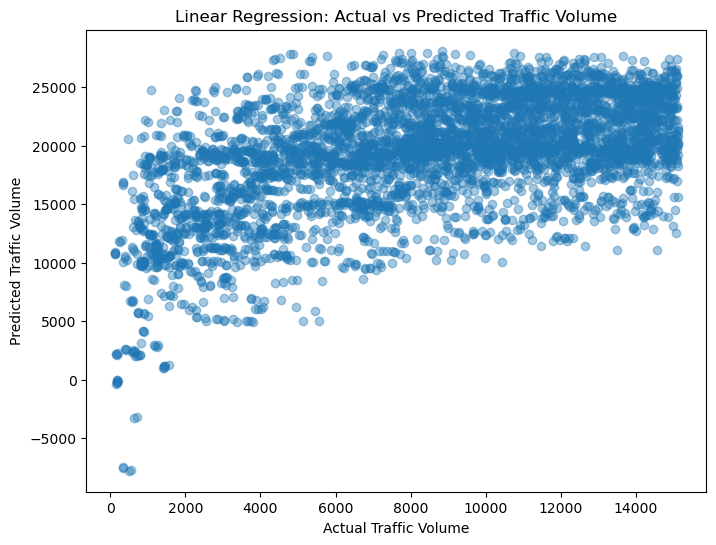

In [45]:
import matplotlib.pyplot as plt

reg_pd = reg_predictions.select("all_motor_vehicles", "prediction").limit(5000).toPandas()

plt.figure(figsize=(8,6))
plt.scatter(reg_pd["all_motor_vehicles"], reg_pd["prediction"], alpha=0.4)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Linear Regression: Actual vs Predicted Traffic Volume")
plt.show()

## 2. Classification grouped bar chart

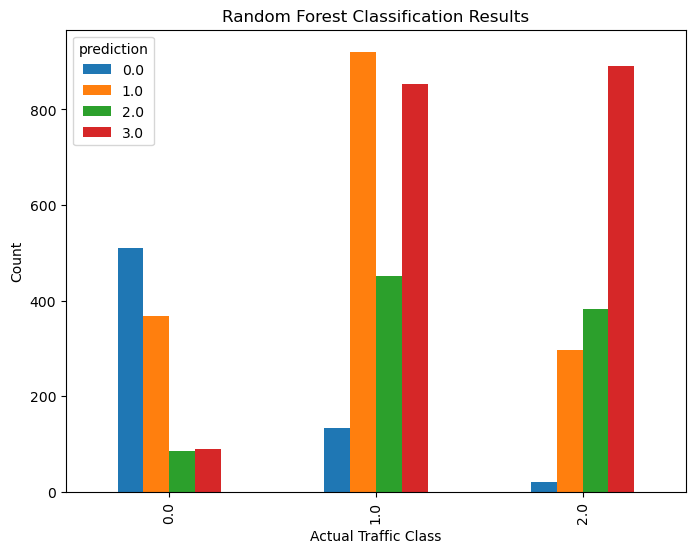

In [48]:
cls_pd = rf_predictions.select("traffic_class", "prediction").limit(5000).toPandas()

cls_counts = cls_pd.groupby(["traffic_class", "prediction"]).size().unstack(fill_value=0)

cls_counts.plot(kind="bar", figsize=(8,6))
plt.xlabel("Actual Traffic Class")
plt.ylabel("Count")
plt.title("Random Forest Classification Results")
plt.show()

## 3. Cluster distribution bar chart

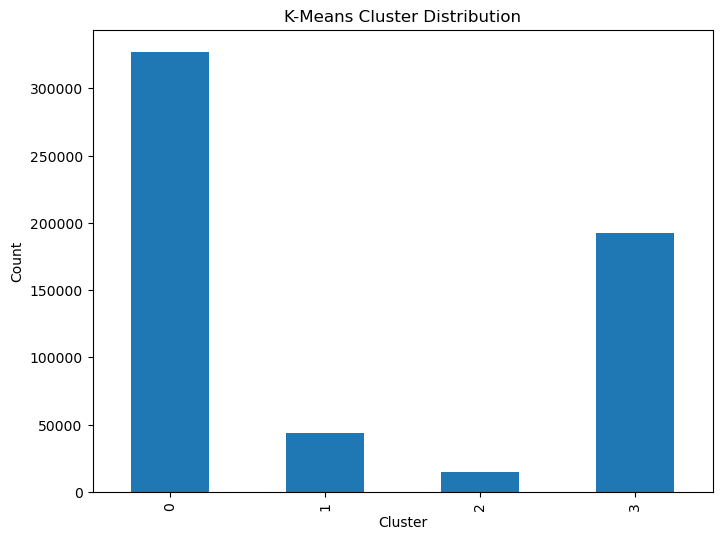

In [52]:
cluster_pd = cluster_results.select("cluster").toPandas()

cluster_pd["cluster"].value_counts().sort_index().plot(kind="bar", figsize=(8,6))
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("K-Means Cluster Distribution")
plt.show()

## 4. Cluster profile bar chart

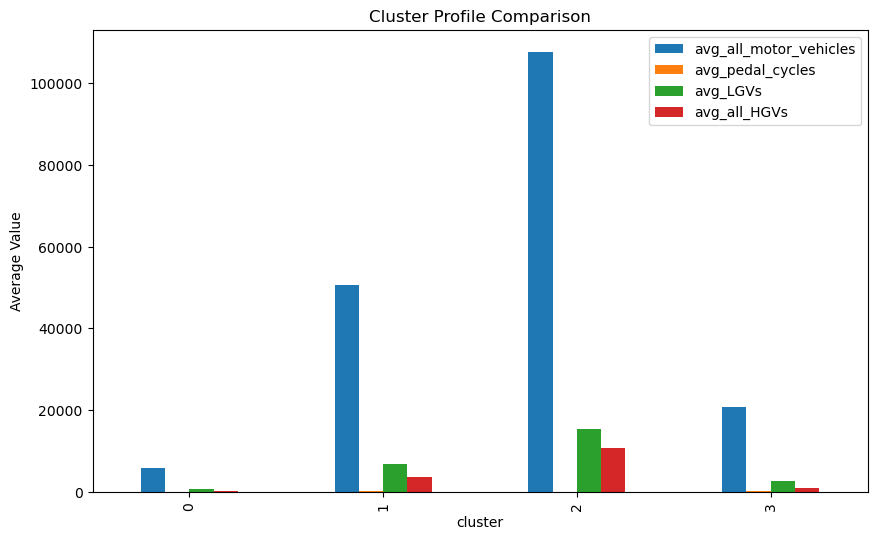

In [56]:
cluster_profile_pd = cluster_profile.toPandas().sort_values("cluster")

cluster_profile_pd.plot(
    x="cluster",
    y=["avg_all_motor_vehicles", "avg_pedal_cycles", "avg_LGVs", "avg_all_HGVs"],
    kind="bar",
    figsize=(10,6)
)
plt.title("Cluster Profile Comparison")
plt.ylabel("Average Value")
plt.show()